## run inference on Image

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n-obb.pt")  # load an official model

# Predict with the model
results = model("https://ultralytics.com/images/boats.jpg")  # predict on an image



image 1/1 c:\Users\Aditya Banerjee\Documents\Github\Nasa-challenge\boats.jpg: 576x1024 172 ships, 5 harbors, 249.0ms
Speed: 42.4ms preprocess, 249.0ms inference, 79.6ms postprocess per image at shape (1, 3, 576, 1024)


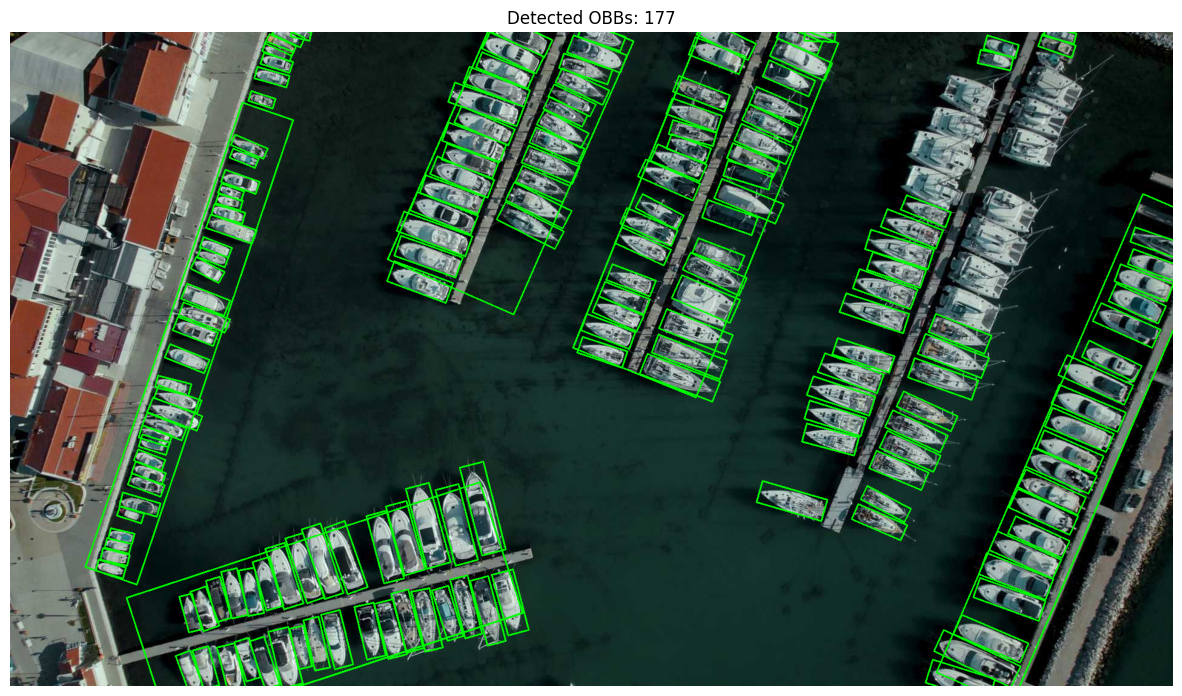

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def display_obbs(result, xywhr, save_path='obb_detections.png'):
    
    img = result.orig_img.copy()
    
    for i, box in enumerate(xywhr):
        cx, cy, w, h, angle = box.tolist()
        
        # Create rotated rectangle and get corner points
        rect = ((cx, cy), (w, h), np.degrees(angle))
        box_points = cv2.boxPoints(rect)
        box_points = np.intp(box_points)
        
        # Draw the rotated rectangle
        cv2.drawContours(img, [box_points], 0, (0, 255, 0), 2)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected OBBs: {len(xywhr)}")
    plt.axis("off")
    plt.savefig(save_path)
    # plt.show()

# Access the results
for result in results:
    xywhr = result.obb.xywhr  # center-x, center-y, width, height, angle (radians)
    xyxyxyxy = result.obb.xyxyxyxy  # polygon format with 4-points
    names = [result.names[cls.item()] for cls in result.obb.cls.int()]  # class name of each box
    confs = result.obb.conf  # confidence score of each box
    # Function to display all OBBs using xywhr
    display_obbs(result, xywhr)

## Run Inference on Test Data

Use the cell below to run inference with your trained model. Update the paths as needed.

Utility Functions

In [5]:
from yolo_ellipse.test_inference import run_inference

print("Inference module loaded! Use run_inference() to make predictions.")

Inference module loaded! Use run_inference() to make predictions.


In [6]:
# ============================================
# INFERENCE CONFIGURATION - UPDATE THESE PATHS
# ============================================

# Path to your trained YOLO OBB model
MODEL_PATH = "./runs/train/crater_obb_11n/weights/best.pt"  # Update this!

# Directory containing test images
TEST_DIR = "./test"  # Update this!

# Output CSV file path
OUTPUT_CSV = "./predictions.csv"

# Inference parameters
CONF_THRESHOLD = 0.25  # Confidence threshold
IOU_THRESHOLD = 0.45   # IoU threshold for NMS
MAX_DET = 100          # Max detections per image
DEVICE = ""            # "" for auto, "0" for GPU, "cpu" for CPU


In [ ]:
# Run inference
predictions = run_inference(
    model_path=MODEL_PATH,
    test_dir=TEST_DIR,
    output_csv=OUTPUT_CSV,
    conf_threshold=CONF_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
    max_det=MAX_DET,
    device=DEVICE,
    include_confidence=False  # Set True to include confidence scores
)

print(f"\nDone! Generated {len(predictions)} predictions.")
print(f"Results saved to: {OUTPUT_CSV}")

Loading model from: ./runs/train/crater_obb_11n/weights/best.pt
Model loaded successfully!
Found 1350 images in ./test
Processing 100/1350...
Processing 200/1350...
Processing 300/1350...
Processing 400/1350...
Processing 500/1350...
Processing 600/1350...
Processing 700/1350...
Processing 800/1350...
Processing 900/1350...
Processing 1000/1350...
Processing 1100/1350...
Processing 1200/1350...
Processing 1300/1350...
Total predictions: 50678
Predictions saved to: ./predictions.csv

Done! Generated 50678 predictions.
Results saved to: ./predictions.csv


## Visualize Predictions

Optionally visualize some predictions on sample images.

In [ ]:
# ============================================
# INFERENCE CONFIGURATION - UPDATE THESE PATHS
# ============================================

# Path to your trained YOLO OBB model
MODEL_PATH = "./runs/train/crater_obb_11n/weights/best.pt"  # Update this!

# Directory containing test images
TEST_DIR = "./test"  # Update this!


Loading model from: ./runs/train/crater_obb_11n/weights/best.pt
Model loaded successfully!

Processing sample 1/3: test\altitude06\longitude01\orientation05_light02.png
Saved visualization to: ./visualizations/sample_1_orientation05_light02.png


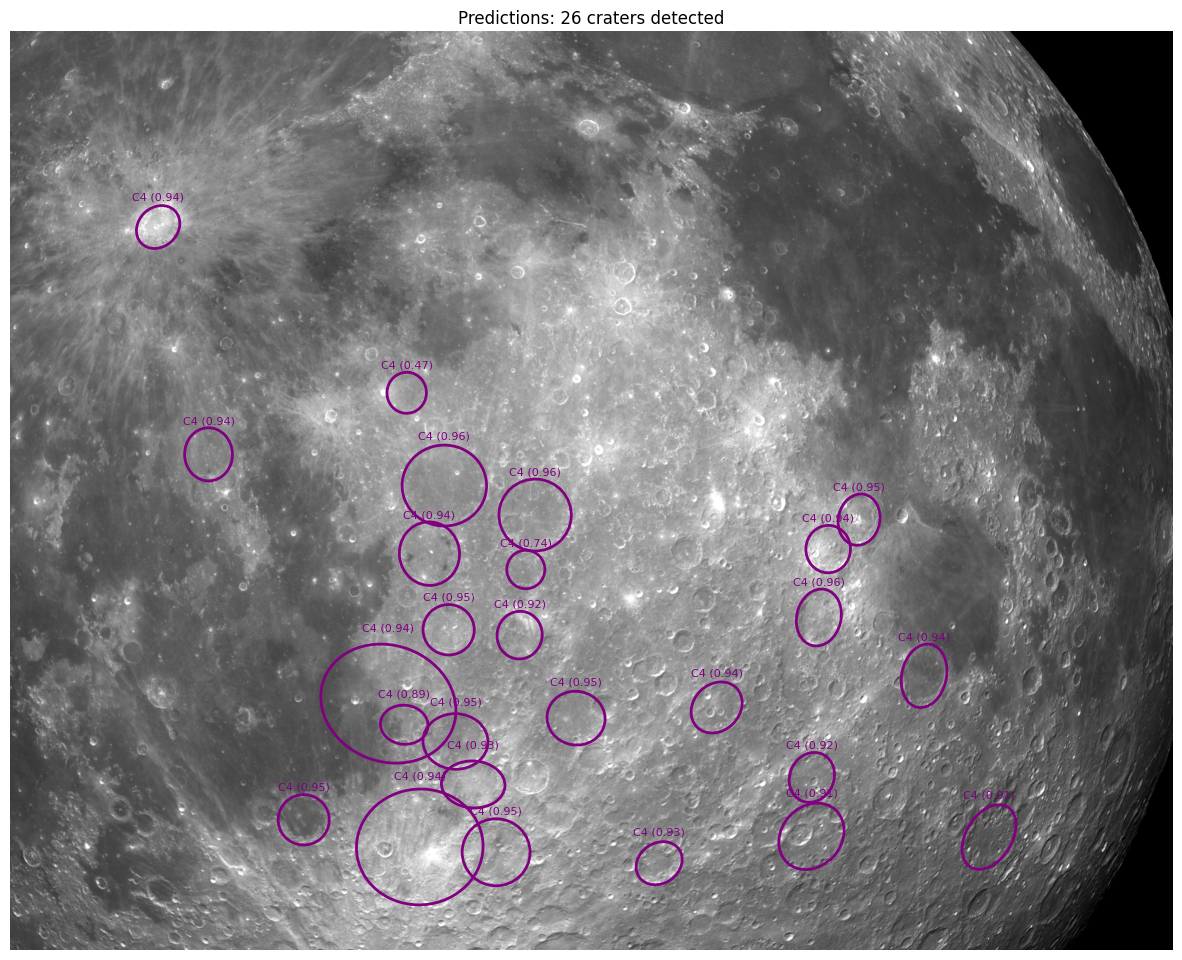


Processing sample 2/3: test\altitude09\longitude02\orientation10_light02.png
Saved visualization to: ./visualizations/sample_2_orientation10_light02.png


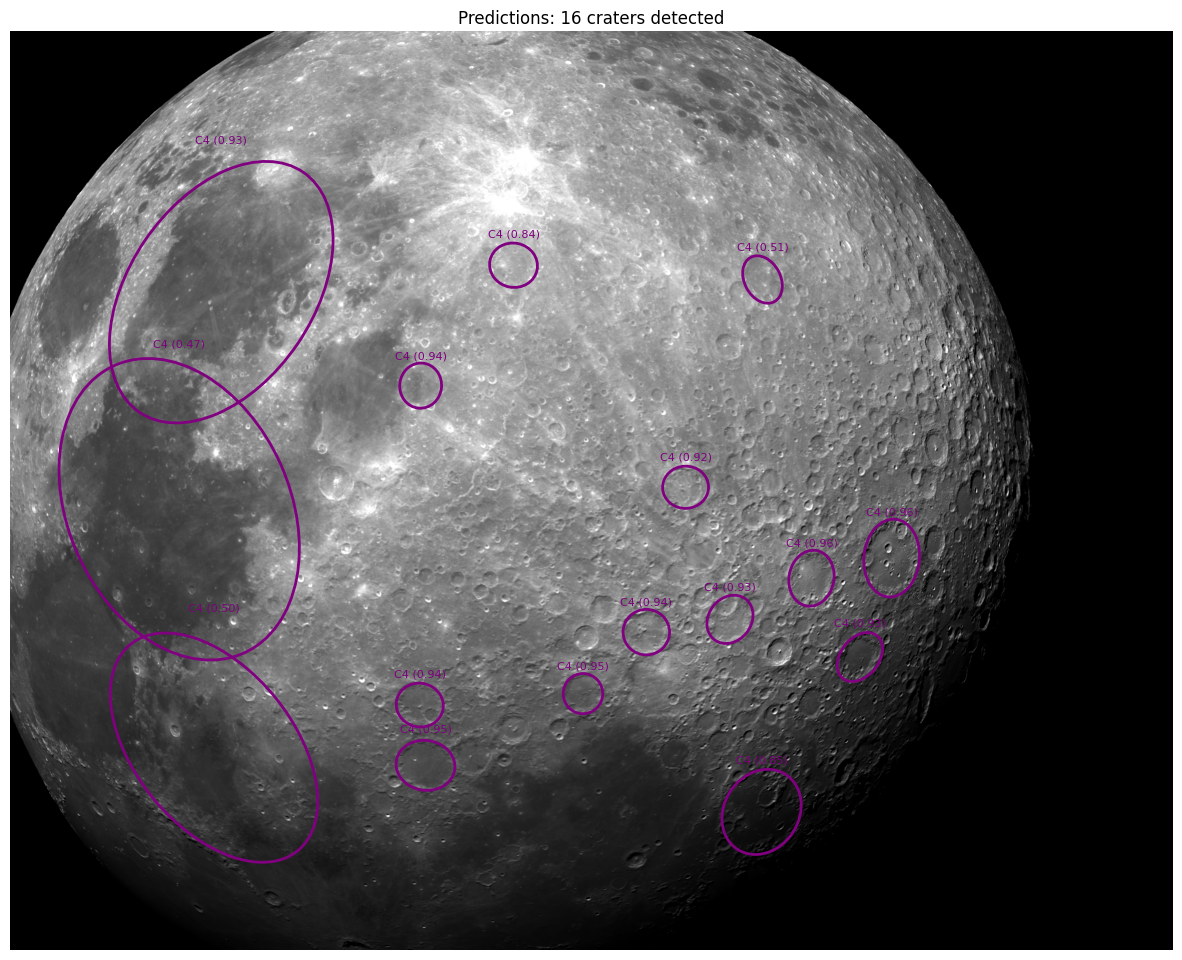


Processing sample 3/3: test\altitude10\longitude04\orientation01_light04.png
Saved visualization to: ./visualizations/sample_3_orientation01_light04.png


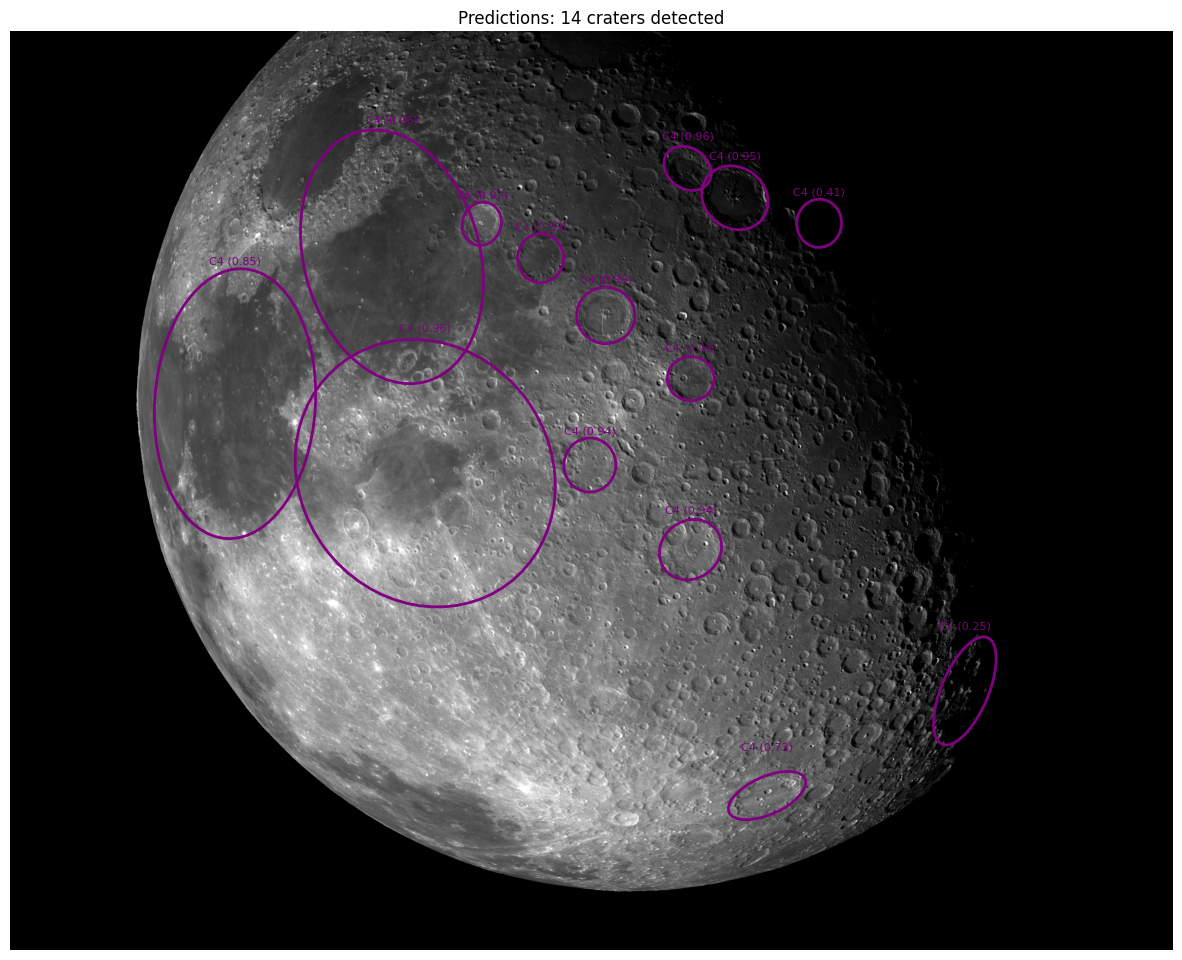

In [2]:
# Example: Visualize on a few sample images
# Uncomment and update paths to use:
from yolo_ellipse.test_inference import CraterPredictor, visualize_sample_predictions

predictor = CraterPredictor(MODEL_PATH)
visualize_sample_predictions(predictor, TEST_DIR, num_samples=3, save_dir="./visualizations")

## Compare Predictions vs Ground Truth

Visualize model predictions alongside ground truth annotations on a random training image.

Selected image: altitude09\longitude11\orientation08_light01
Ground truth craters: 41
Image path: ./train\altitude09\longitude11\orientation08_light01.png
Predicted craters: 40


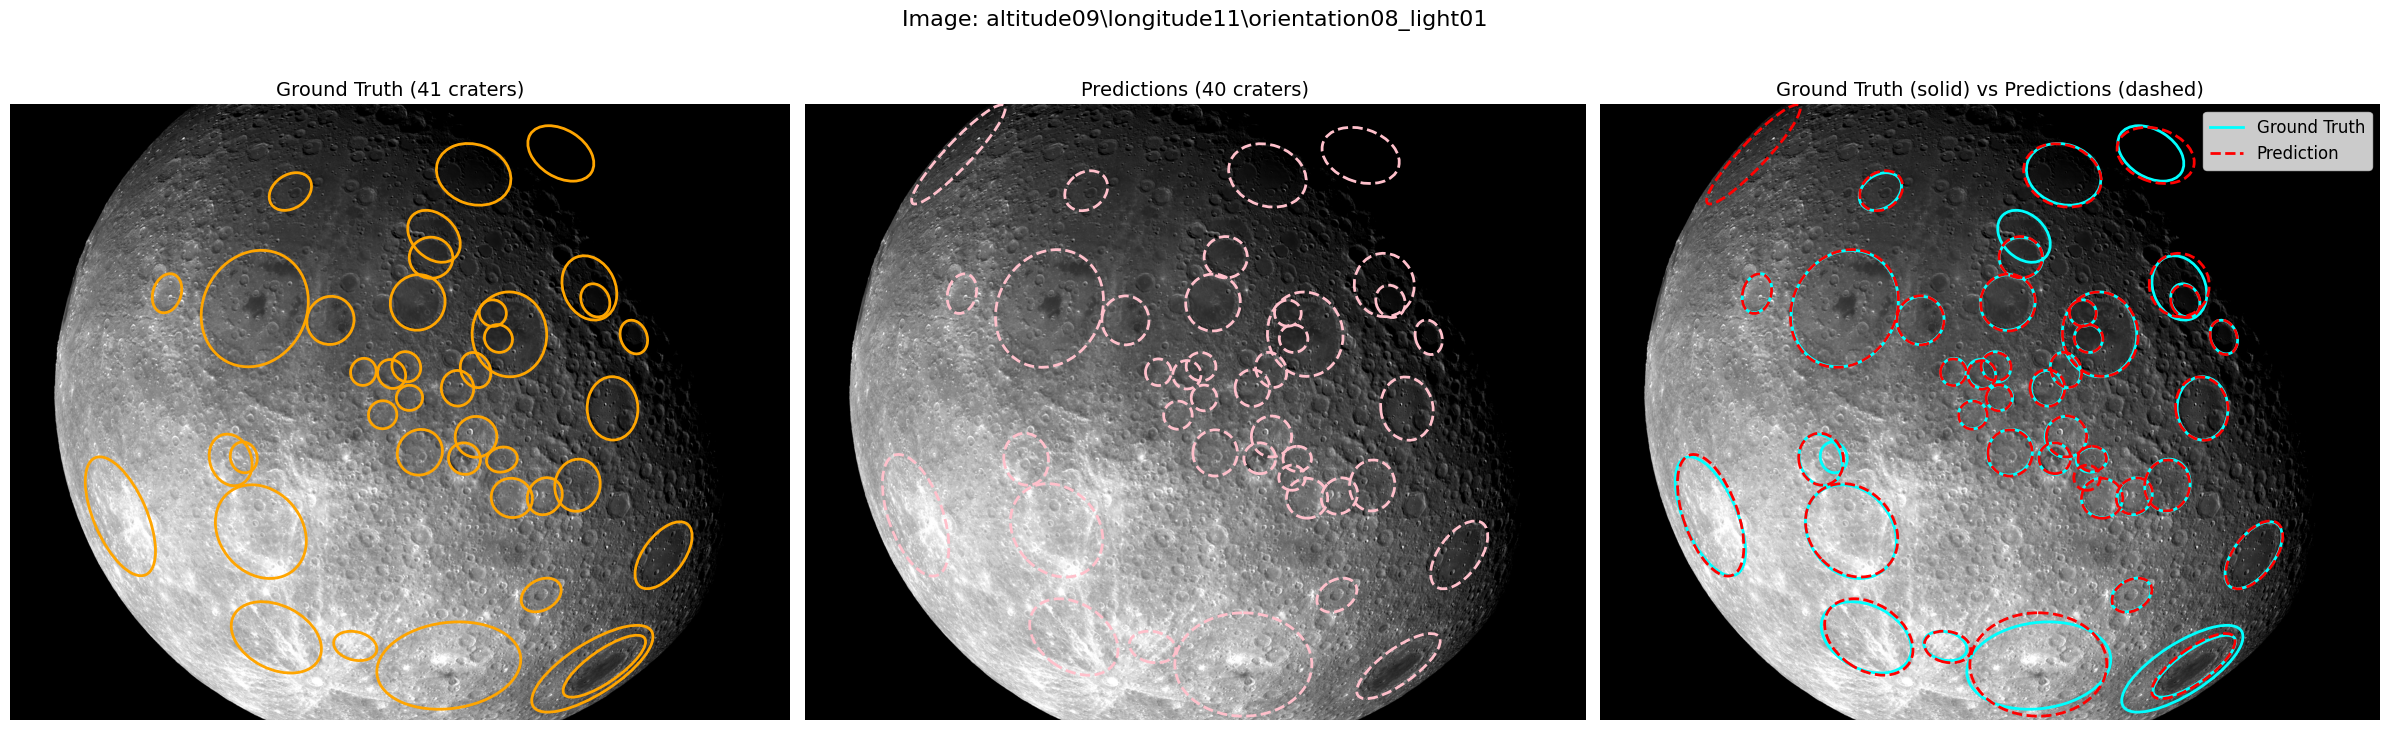


Saved to: ./visualizations/gt_vs_pred_comparison.png


In [3]:
import os
import random
import math
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from ultralytics import YOLO

# ============================================
# CONFIGURATION
# ============================================
MODEL_PATH = "./runs/train/crater_obb_11n/weights/best.pt"
TRAIN_DIR = "./train"
GT_CSV = "./train-gt.csv"

# Load ground truth CSV
gt_df = pd.read_csv(GT_CSV)

# Get unique images
unique_images = gt_df['inputImage'].unique().tolist()

# Select a random image
random_image = random.choice(unique_images)
print(f"Selected image: {random_image}")

# Get ground truth annotations for this image
gt_annotations = gt_df[gt_df['inputImage'] == random_image]
print(f"Ground truth craters: {len(gt_annotations)}")

# Construct image path
parts = random_image.replace('/', '\\').split('\\')
image_path = os.path.join(TRAIN_DIR, parts[0], parts[1], parts[2]) + '.png'
print(f"Image path: {image_path}")

# Load model and run prediction
model = YOLO(MODEL_PATH)
results = model.predict(source=image_path, conf=0.25, iou=0.45, verbose=False)


def obb_to_ellipse_params(obb_points):
    """Convert OBB corners to ellipse parameters."""
    points = np.array(obb_points).reshape(4, 2)
    
    cx = np.mean(points[:, 0])
    cy = np.mean(points[:, 1])
    
    edge1 = points[1] - points[0]
    edge2 = points[3] - points[0]
    
    len1 = np.linalg.norm(edge1)
    len2 = np.linalg.norm(edge2)
    
    if len1 >= len2:
        semimajor, semiminor = len1 / 2, len2 / 2
        rotation_rad = math.atan2(edge1[1], edge1[0])
    else:
        semimajor, semiminor = len2 / 2, len1 / 2
        rotation_rad = math.atan2(edge2[1], edge2[0])
    
    rotation_deg = math.degrees(rotation_rad)
    return cx, cy, semimajor, semiminor, rotation_deg


# Extract predictions
pred_ellipses = []
for result in results:
    if result.obb is not None and result.obb.xyxyxyxy is not None:
        boxes = result.obb.xyxyxyxy.cpu().numpy()
        classes = result.obb.cls.cpu().numpy()
        confs = result.obb.conf.cpu().numpy()
        
        for i in range(len(boxes)):
            cx, cy, semimajor, semiminor, rotation = obb_to_ellipse_params(boxes[i])
            pred_ellipses.append({
                'cx': cx, 'cy': cy,
                'semimajor': semimajor, 'semiminor': semiminor,
                'rotation': rotation,
                'class': int(classes[i]),
                'conf': float(confs[i])
            })

print(f"Predicted craters: {len(pred_ellipses)}")


# ============================================
# VISUALIZATION
# ============================================
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Colors for different classes
class_colors_gt = ['cyan', 'lime', 'yellow', 'magenta', 'orange']
class_colors_pred = ['red', 'green', 'blue', 'purple', 'pink']

# --- Plot 1: Ground Truth Only ---
axes[0].imshow(img)
axes[0].set_title(f'Ground Truth ({len(gt_annotations)} craters)', fontsize=14)
for _, row in gt_annotations.iterrows():
    ellipse = Ellipse(
        (row['ellipseCenterX(px)'], row['ellipseCenterY(px)']),
        width=2 * row['ellipseSemimajor(px)'],
        height=2 * row['ellipseSemiminor(px)'],
        angle=row['ellipseRotation(deg)'],
        fill=False,
        edgecolor=class_colors_gt[int(row['crater_classification']) % len(class_colors_gt)],
        linewidth=2
    )
    axes[0].add_patch(ellipse)
axes[0].axis('off')

# --- Plot 2: Predictions Only ---
axes[1].imshow(img)
axes[1].set_title(f'Predictions ({len(pred_ellipses)} craters)', fontsize=14)
for pred in pred_ellipses:
    ellipse = Ellipse(
        (pred['cx'], pred['cy']),
        width=2 * pred['semimajor'],
        height=2 * pred['semiminor'],
        angle=pred['rotation'],
        fill=False,
        edgecolor=class_colors_pred[pred['class'] % len(class_colors_pred)],
        linewidth=2,
        linestyle='--'
    )
    axes[1].add_patch(ellipse)
axes[1].axis('off')

# --- Plot 3: Both Overlaid ---
axes[2].imshow(img)
axes[2].set_title('Ground Truth (solid) vs Predictions (dashed)', fontsize=14)

# Ground truth (solid lines)
for _, row in gt_annotations.iterrows():
    ellipse = Ellipse(
        (row['ellipseCenterX(px)'], row['ellipseCenterY(px)']),
        width=2 * row['ellipseSemimajor(px)'],
        height=2 * row['ellipseSemiminor(px)'],
        angle=row['ellipseRotation(deg)'],
        fill=False,
        edgecolor='cyan',
        linewidth=2,
        label='Ground Truth'
    )
    axes[2].add_patch(ellipse)

# Predictions (dashed lines)
for pred in pred_ellipses:
    ellipse = Ellipse(
        (pred['cx'], pred['cy']),
        width=2 * pred['semimajor'],
        height=2 * pred['semiminor'],
        angle=pred['rotation'],
        fill=False,
        edgecolor='red',
        linewidth=2,
        linestyle='--',
        label='Prediction'
    )
    axes[2].add_patch(ellipse)

axes[2].axis('off')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='cyan', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Prediction')
]
axes[2].legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.suptitle(f'Image: {random_image}', fontsize=16)
plt.tight_layout()
plt.savefig('./visualizations/gt_vs_pred_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to: ./visualizations/gt_vs_pred_comparison.png")